# Cloud Computing Project — Results Analysis

This notebook processes the CSVs produced by Locust in `../load-tests/results/` and produces the charts that go into the final report.

**Before running**: make sure `load-tests/run_scenarios.bat` has finished, and that there are CSV files in the results folder.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path

RESULTS_DIR = Path('../../load-tests/results')
CHARTS_DIR = Path('charts')
CHARTS_DIR.mkdir(exist_ok=True)

# Find all per-scenario stats files
stats_files = sorted(RESULTS_DIR.glob('*_stats.csv'))
print(f'Found {len(stats_files)} scenario files')
stats_files[:5]

Found 72 scenario files


[WindowsPath('../load-tests/results/edge_large_100u_rep1_stats.csv'),
 WindowsPath('../load-tests/results/edge_large_100u_rep2_stats.csv'),
 WindowsPath('../load-tests/results/edge_large_10u_rep1_stats.csv'),
 WindowsPath('../load-tests/results/edge_large_10u_rep2_stats.csv'),
 WindowsPath('../load-tests/results/edge_large_1u_rep1_stats.csv')]

## 1. Load all scenarios into a single DataFrame

Filenames are like `grayscale_medium_50u_rep1_stats.csv`. We parse those into columns.

In [10]:
PATTERN = re.compile(r'(?P<op>\w+?)_(?P<size>small|medium|large)_(?P<users>\d+)u_rep(?P<rep>\d+)_stats\.csv')

rows = []
for f in stats_files:
    m = PATTERN.match(f.name)
    if not m:
        continue
    df = pd.read_csv(f)
    aggr = df[df['Name'] == 'Aggregated']
    if aggr.empty:
        continue
    a = aggr.iloc[0]
    rows.append({
        'operation': m.group('op'),
        'size': m.group('size'),
        'users': int(m.group('users')),
        'rep': int(m.group('rep')),
        'requests': a['Request Count'],
        'failures': a['Failure Count'],
        'rps': a['Requests/s'],
        'avg_ms': a['Average Response Time'],
        'p50_ms': a['Median Response Time'],
        'p95_ms': a['95%'] if '95%' in a.index else None,
        'p99_ms': a['99%'] if '99%' in a.index else None,
    })

data = pd.DataFrame(rows)
data['error_rate'] = data['failures'] / data['requests'].clip(lower=1)
data.head()

,operation,size,users,rep,requests,failures,rps,avg_ms,p50_ms,p95_ms,p99_ms,error_rate
0,edge,large,100,1,90,11,0.760978,59322.156959,62000,104000,109000,0.122222
1,edge,large,100,2,91,14,0.773248,52663.383587,52000,91000,108000,0.153846
2,edge,large,10,1,148,0,1.242609,5873.587980,5800,11000,18000,0.000000
3,edge,large,10,2,137,0,1.164502,6479.773582,5800,14000,23000,0.000000
4,edge,large,1,1,30,0,0.253049,2045.654247,2000,2900,3100,0.000000


## 2. Chart — p95 response time vs concurrent users

One curve per operation, averaged across repetitions and across image sizes.

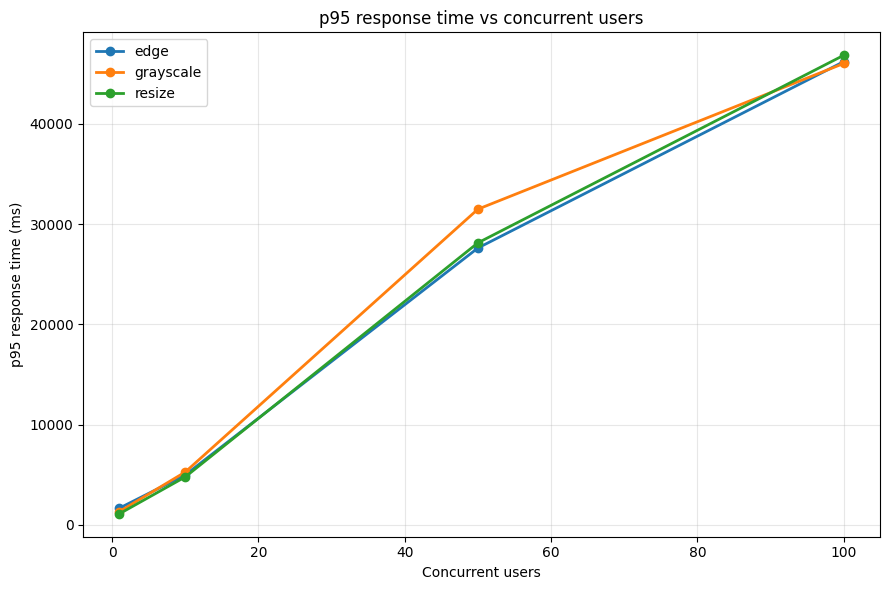

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
for op in data['operation'].unique():
    sub = data[data['operation'] == op].groupby('users')['p95_ms'].mean().reset_index()
    ax.plot(sub['users'], sub['p95_ms'], marker='o', linewidth=2, label=op)

ax.set_xlabel('Concurrent users')
ax.set_ylabel('p95 response time (ms)')
ax.set_title('p95 response time vs concurrent users')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'p95_vs_users.png', dpi=150)
plt.show()

## 3. Chart — Throughput (req/s) vs concurrent users

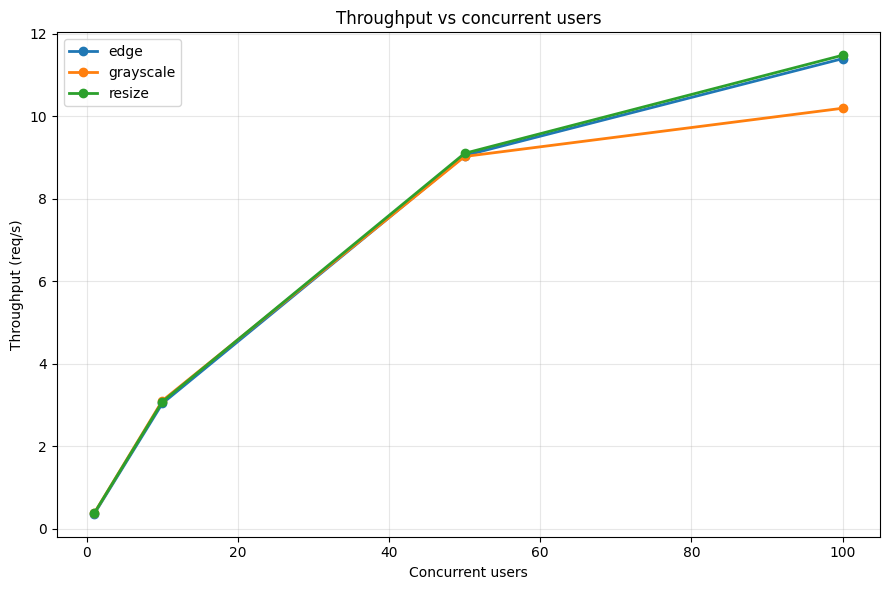

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))
for op in data['operation'].unique():
    sub = data[data['operation'] == op].groupby('users')['rps'].mean().reset_index()
    ax.plot(sub['users'], sub['rps'], marker='o', linewidth=2, label=op)

ax.set_xlabel('Concurrent users')
ax.set_ylabel('Throughput (req/s)')
ax.set_title('Throughput vs concurrent users')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'throughput_vs_users.png', dpi=150)
plt.show()

## 4. Chart — Error rate vs concurrent users

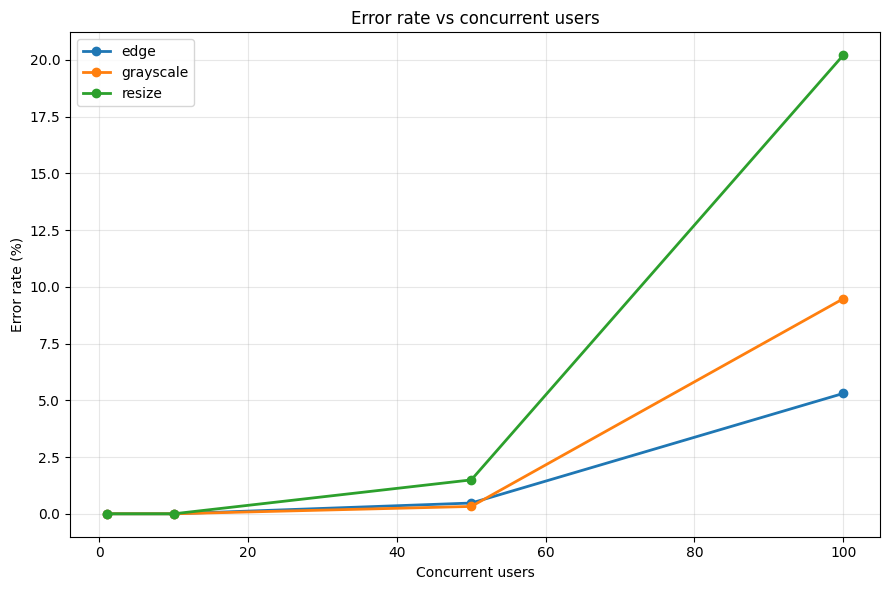

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))
for op in data['operation'].unique():
    sub = data[data['operation'] == op].groupby('users')['error_rate'].mean().reset_index()
    ax.plot(sub['users'], sub['error_rate'] * 100, marker='o', linewidth=2, label=op)

ax.set_xlabel('Concurrent users')
ax.set_ylabel('Error rate (%)')
ax.set_title('Error rate vs concurrent users')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'errors_vs_users.png', dpi=150)
plt.show()

## 5. Chart — p95 response time vs image size

Bar chart grouped by operation, showing how each operation responds to different image sizes (averaged across all load levels).

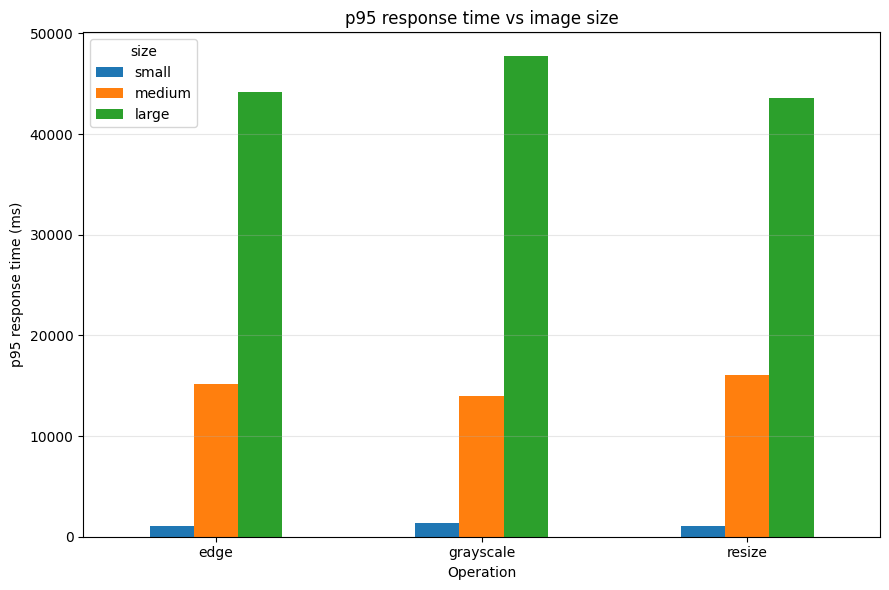

In [14]:
pivot = data.groupby(['operation', 'size'])['p95_ms'].mean().unstack()
pivot = pivot[['small', 'medium', 'large']]  # order columns

ax = pivot.plot(kind='bar', figsize=(9, 6))
ax.set_xlabel('Operation')
ax.set_ylabel('p95 response time (ms)')
ax.set_title('p95 response time vs image size')
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'p95_vs_size.png', dpi=150)
plt.show()

## 6. Chart — Cold starts

Loaded from `cold_starts.csv` produced by `cold_start_test.py`.

In [15]:
cold_path = RESULTS_DIR / 'cold_starts.csv'
if cold_path.exists():
    cold = pd.read_csv(cold_path)
    fig, ax = plt.subplots(figsize=(9, 6))
    for op in cold['operation'].unique():
        sub = cold[cold['operation'] == op]['response_time_ms']
        ax.hist(sub, bins=10, alpha=0.5, label=op)
    ax.set_xlabel('Response time (ms)')
    ax.set_ylabel('Count')
    ax.set_title('Cold start response time distribution')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(CHARTS_DIR / 'cold_starts.png', dpi=150)
    plt.show()
else:
    print('cold_starts.csv not found — run cold_start_test.py first')

cold_starts.csv not found — run cold_start_test.py first


## 7. Summary table for the report

In [16]:
summary = data.groupby(['operation', 'size', 'users']).agg(
    avg_p95_ms=('p95_ms', 'mean'),
    avg_rps=('rps', 'mean'),
    avg_error_pct=('error_rate', lambda x: x.mean() * 100),
).round(1)
summary.to_csv(CHARTS_DIR / 'summary_table.csv')
summary

avg_p95_ms  avg_rps  avg_error_pct
operation size   users                                    
edge      large  1          3650.0      0.2            0.0
                 10        12500.0      1.2            0.0
                 50        63000.0      1.1            1.1
                 100       97500.0      0.8           13.8
          medium 1           995.0      0.4            0.0
                 10         2100.0      3.3            0.0
                 50        19500.0      4.1            0.3
                 100       38000.0      3.8            2.1
          small  1           335.0      0.5            0.0
                 10          315.0      4.6            0.0
                 50          355.0     21.9            0.0
                 100        3150.0     29.6            0.0
grayscale large  1          2400.0      0.3            0.0
                 10        13500.0      1.2            0.0
                 50        76000.0      1.1            0.8
                 100       99000.0      0.8           27.2
          medium 1           930.0      0.4            0.0
                 10         2000.0      3.5            0.0
                 50        18000.0      4.1            0.2
                 100       35000.0      3.8            1.1
          small  1           640.0      0.5            0.0
                 10          285.0      4.6            0.0
                 50          475.0     21.8            0.0
                 100        4100.0     26.0            0.1
resize    large  1          2200.0      0.3            0.0
                 10        12000.0      1.3            0.0
                 50        63500.0      1.1            3.8
                 100       96500.0      1.1           56.6
          medium 1           795.0      0.4            0.0
                 10         2000.0      3.4            0.0
                 50        20500.0      4.1            0.7
                 100       41000.0      3.9            4.1
          small  1           295.0      0.4            0.0
                 10          320.0      4.5            0.0
                 50          400.0     22.1            0.0
                 100        3050.0     29.5            0.0

## Done

All charts are saved in `analysis/charts/`. Drop them into the Word report.